# <center> Homework 127

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA
from itertools import product

2026-02-12 18:25:06.319455: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-12 18:25:07.508453: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 18:25:16.061756: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Task 1



да се имплементира предсказване на броя пътници чрез готовия клас ARIMA

    да се намерят оптималните хипер-параметри с grid search
    да се изчислят оценките на най-добрия модел и да се сравнят с друите модели


In [8]:
path = Path("datasets/CTA_-_Ridership_-_Daily_Boarding_Totals_20260211.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1) # no need for total, it's just bus + rail
df = df.drop_duplicates() # remove duplicated months (2011-10 and 2014-07)

df['bus'] = df['bus'].str.replace(",", "").astype(float)
df['rail'] = df['rail'].str.replace(",", "").astype(float)

/tmp/ipykernel_42343/3790963653.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df[['bus', 'rail']].resample('M').mean()


<Axes: xlabel='date'>

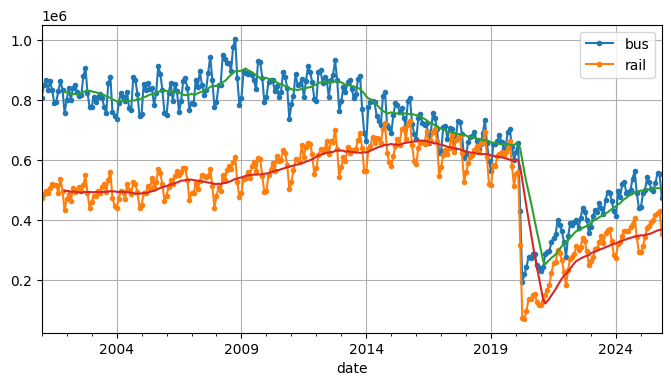

In [9]:
df_monthly = df[['bus', 'rail']].resample('M').mean()
rolling_average_12_months = df_monthly.rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))

df_monthly.plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)

In [14]:
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")

y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today], # train on data up to "today"
                order=(1, 0, 0),
                seasonal_order=(0, 1, 1, 7))
                
    model = model.fit() # note that we retrain the model every day!
    y_pred = model.forecast()[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean() # returns 32,040.7

/tmp/ipykernel_42343/1555740968.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.forecast()[0]
/tmp/ipykernel_42343/1555740968.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.forecast()[0]
/tmp/ipykernel_42343/1555740968.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.forecast()[0]
/tmp/ipykernel_42343/1555740968.py:12: FutureWarning: Series.__getitem__ treating keys as posi

<Axes: >

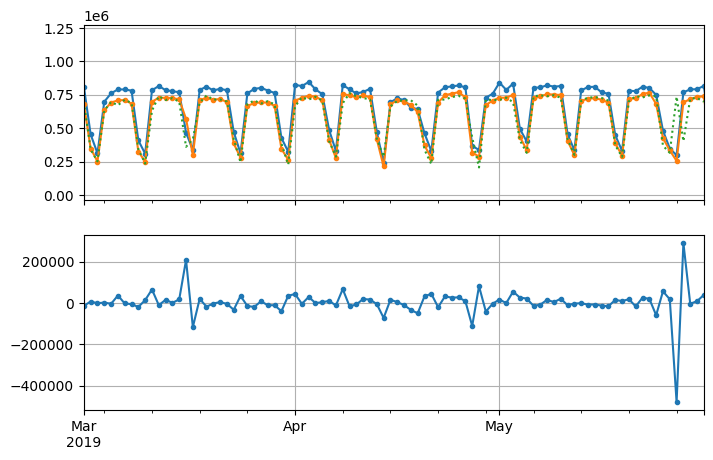

In [23]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
diff = rail_series - y_preds

df.plot(ax=axs[0], legend=False, marker=".") 
y_preds.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff.loc[time_period].plot(ax=axs[1], grid=True, marker=".")

/tmp/ipykernel_44792/1441731785.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rail_df.iloc[:5000].resample('M').mean().plot(ax=ax[0])
/tmp/ipykernel_44792/1441731785.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rail_df.iloc[5000:6000].resample('M').mean().plot(ax=ax[1])


Text(0.5, 1.0, 'Test Period')

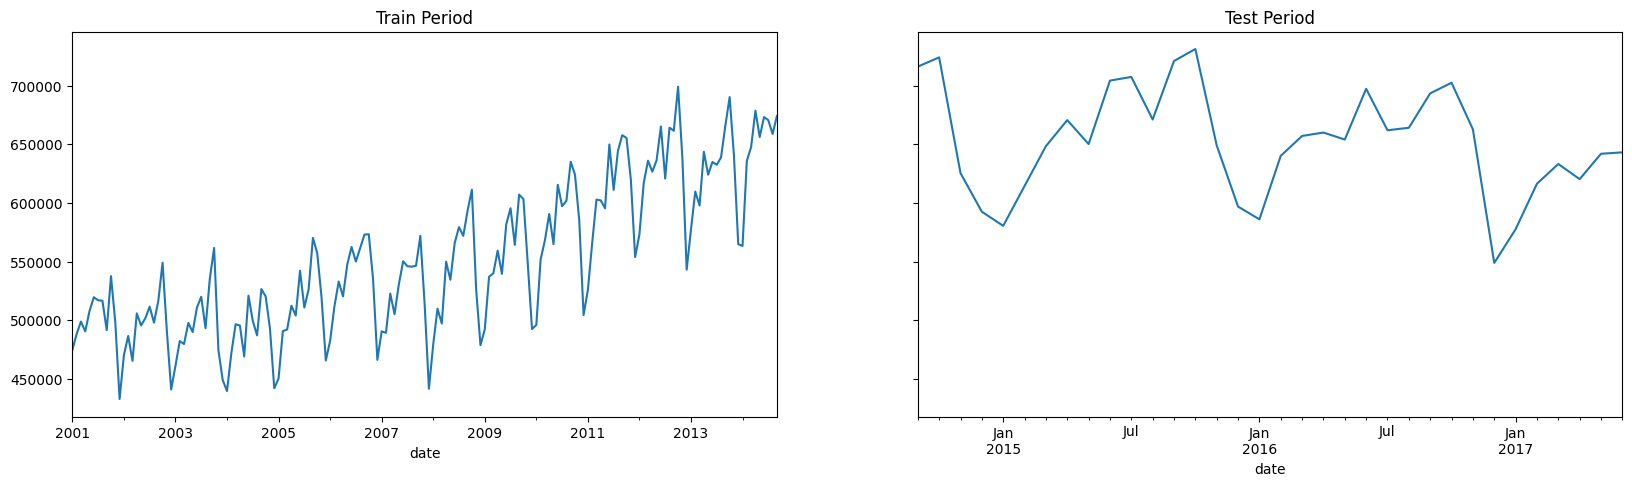

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5), sharey=True)
rail_df = df['rail'].asfreq("D")

rail_df.iloc[:5000].resample('M').mean().plot(ax=ax[0])
ax[0].set_title('Train Period')

rail_df.iloc[5000:6000].resample('M').mean().plot(ax=ax[1])
ax[1].set_title('Test Period')

In [26]:
train = rail_df.iloc[:5000]
test  = rail_df.iloc[5000:6000]

In [29]:
p_ranges = range(0, 3)
d_ranges = range(0, 2)
q_ranges = range(0, 3)

P_ranges = range(0, 2)
D_ranges = range(0, 2)
Q_ranges = range(0, 2)

s = 7

param_combinations = product(p_ranges, d_ranges, q_ranges, P_ranges, D_ranges, Q_ranges)
params_count = len(list(param_combinations))
f'Combinations count: {params_count}'

'Combinations count: 144'

In [34]:
p_ranges = range(0, 3)
d_ranges = range(0, 2)
q_ranges = range(0, 3)

P_ranges = range(0, 2)
D_ranges = range(0, 2)
Q_ranges = range(0, 2)

s = 7
param_combinations = product(p_ranges, d_ranges, q_ranges, P_ranges, D_ranges, Q_ranges)

best_mae = float('inf')
best_mape = None
best_model = None
best_model_preds = None

for i, (p, d, q, P, D, Q) in enumerate(param_combinations, start=1):
    print(f'Model {i}/{params_count}\nParams{p, d, q, P, D, Q}\nBest MAPE: {best_mape or 1:.2f}\n\n')

    model = ARIMA(train, 
                order=(p, d, q),
                seasonal_order=(P, D, Q, s))
                
    model = model.fit() 
    y_preds = model.forecast(steps=len(test))
    y_preds = pd.Series(y_preds, index=test.index)

    diff = y_preds - test
    mae = (diff).abs().mean()
    mape = (diff / test).abs().mean()

    if mae < best_mae:
        best_mae = mae
        best_mape = mape
        best_model = model
        best_model_preds = y_preds


f'Best MAE {best_mae}; Best MAPE {best_mape}'

Model 1/144
Params(0, 0, 0, 0, 0, 0)
Best MAPE: 1.00


Model 2/144
Params(0, 0, 0, 0, 0, 1)
Best MAPE: 0.33


Model 3/144
Params(0, 0, 0, 0, 1, 0)
Best MAPE: 0.33


Model 4/144
Params(0, 0, 0, 0, 1, 1)
Best MAPE: 0.14


Model 5/144
Params(0, 0, 0, 1, 0, 0)
Best MAPE: 0.14


Model 6/144
Params(0, 0, 0, 1, 0, 1)
Best MAPE: 0.14


Model 7/144
Params(0, 0, 0, 1, 1, 0)
Best MAPE: 0.14


Model 8/144
Params(0, 0, 0, 1, 1, 1)
Best MAPE: 0.14


Model 9/144
Params(0, 0, 1, 0, 0, 0)
Best MAPE: 0.12


Model 10/144
Params(0, 0, 1, 0, 0, 1)
Best MAPE: 0.12


Model 11/144
Params(0, 0, 1, 0, 1, 0)
Best MAPE: 0.12


Model 12/144
Params(0, 0, 1, 0, 1, 1)
Best MAPE: 0.12


Model 13/144
Params(0, 0, 1, 1, 0, 0)
Best MAPE: 0.12


Model 14/144
Params(0, 0, 1, 1, 0, 1)
Best MAPE: 0.12


Model 15/144
Params(0, 0, 1, 1, 1, 0)
Best MAPE: 0.12


Model 16/144
Params(0, 0, 1, 1, 1, 1)
Best MAPE: 0.12


Model 17/144
Params(0, 0, 2, 0, 0, 0)
Best MAPE: 0.12


Model 18/144
Params(0, 0, 2, 0, 0, 1)
Best MAPE: 0.12


M

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Model 42/144
Params(0, 1, 2, 0, 0, 1)
Best MAPE: 0.12




/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Model 43/144
Params(0, 1, 2, 0, 1, 0)
Best MAPE: 0.12


Model 44/144
Params(0, 1, 2, 0, 1, 1)
Best MAPE: 0.12


Model 45/144
Params(0, 1, 2, 1, 0, 0)
Best MAPE: 0.12




...

Model 143/144
Params(2, 1, 2, 1, 1, 0)
Best MAPE: 0.12




/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Model 144/144
Params(2, 1, 2, 1, 1, 1)
Best MAPE: 0.12




/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


'Best MAE 57605.33900673563; Best MAPE 0.12178629025264377'

### Test Data

<Axes: xlabel='date'>

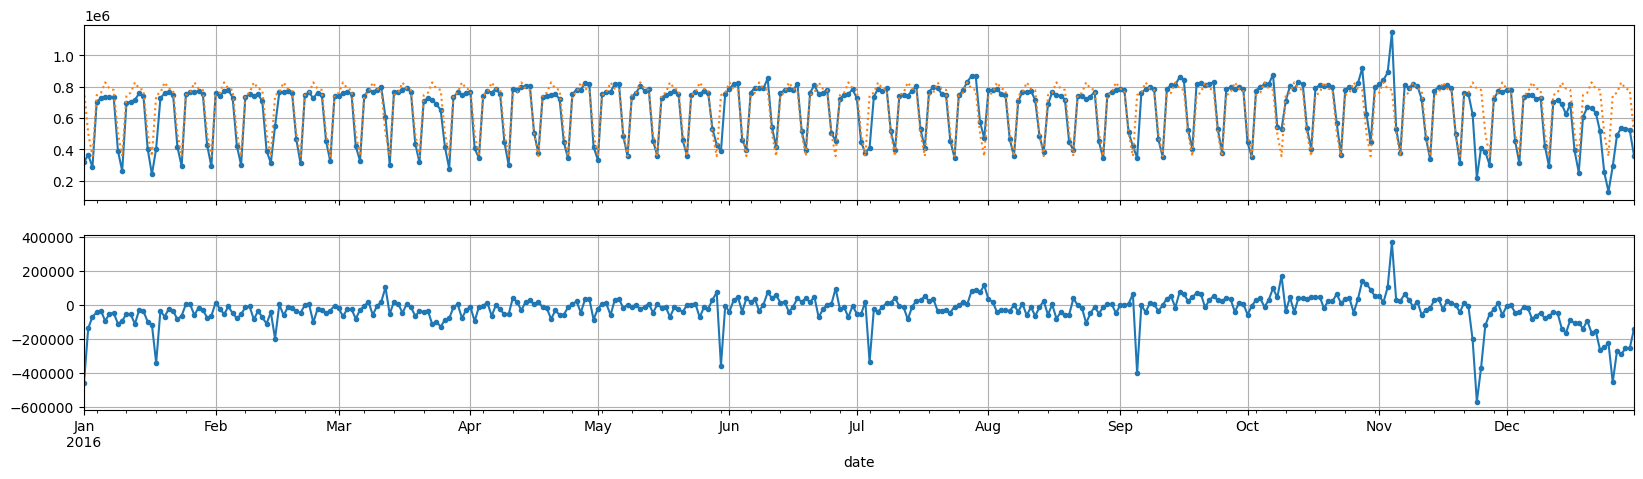

In [40]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))
period = slice('2016-01', '2016-12')
diff = test - best_model_preds

test.plot(ax=axs[0], legend=False, marker=".") 
best_model_preds.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff[period].plot(ax=axs[1], grid=True, marker=".")

In [42]:
mae = diff.abs().mean()
mape = (diff / test).abs().mean()
mse = (diff ** 2).mean()
mspe = ((diff / test) ** 2).mean()

f'MAE: {mae}; MAPE: {mape}; MSE: {mse}; MSPE: {mspe}'

'MAE: 57605.33900673563; MAPE: 0.12178629025264377; MSE: 9075362934.10186; MSPE: 0.09146375434544705'

In [43]:
best_model.params

ar.L1     1.684591e+00
ar.L2    -7.466837e-01
ma.L1    -1.415767e+00
ma.L2     4.561466e-01
sigma2    6.536363e+09
dtype: float64

### Naive Model Shift 1 yaer

<Axes: xlabel='date'>

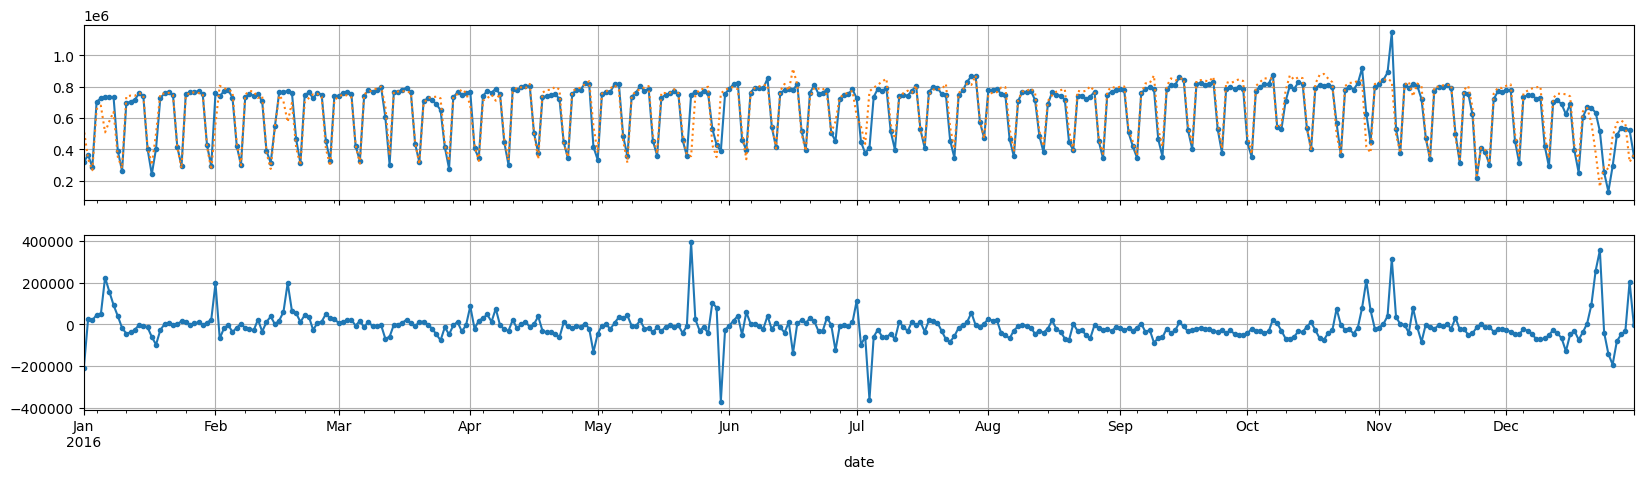

In [ ]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))
period = slice('2016-01', '2016-12')

y_pred_naive = df.shift(52 * 7)['rail'].loc[test.index]
naive_diff = test - y_pred_naive

test.plot(ax=axs[0], legend=False, marker=".") 
y_pred_naive.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

naive_diff[period].plot(ax=axs[1], grid=True, marker=".")

In [51]:
naive_mae = naive_diff.abs().mean()
naive_mape = (naive_diff / test).abs().mean()
naive_mse = (naive_diff ** 2).mean()
naive_mspe = ((naive_diff / test) ** 2).mean()

print('             === SARIMA ===')
print(f'MAE: {mae:.2f}; MAPE: {mape:.2f}; MSE: {mse:.2f}; MSPE: {mspe:.2f}\n')

print('             === NAIVE ===')
print(f'MAE: {naive_mae:.2f}; MAPE: {naive_mape:.2f}; MSE: {naive_mse:.2f}; MSPE: {naive_mspe:.2f}')

             === SARIMA ===
MAE: 57605.34; MAPE: 0.12; MSE: 9075362934.10; MSPE: 0.09

             === NAIVE ===
MAE: 37649.62; MAPE: 0.07; MSE: 4111081678.43; MSPE: 0.02


## Task 2

да се предскаже броя пътници с SimpleRNN след който има Dense layer.

### да се тестват варианти с различен брой неврони в двата слоя (без да се подава тип ден)

In [68]:
df_bus_rail = df[['bus', 'rail']].loc[:'2019-12'] / 1e6

train_ratio = 0.7
train_samples = int(len(df_bus_rail) * train_ratio)

df_bus_rail_train = df_bus_rail.iloc[:train_samples]
df_bus_rail_test = df_bus_rail.iloc[train_samples:]

In [69]:
df_bus_rail_train

,bus,rail
date,,
2001-01-01,0.297192,0.126455
2001-01-02,0.780827,0.501952
2001-01-03,0.824923,0.536432
2001-01-04,0.870021,0.550011
2001-01-05,0.890426,0.557917
...,...,...
2014-04-15,0.844484,0.734464
2014-04-16,0.866995,0.757767
2014-04-17,0.864791,0.770728


In [70]:
frame_length = 100

train_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_bus_rail_train.to_numpy(),
    targets=df_bus_rail_train[frame_length:],
    sequence_length=frame_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_bus_rail_test.to_numpy(),
    targets=df_bus_rail_test[frame_length:],
    sequence_length=frame_length,
    batch_size=32
)

In [71]:
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 2]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(2)
])

model_1.compile(loss=tf.keras.losses.Huber(),
                optimizer=tf.keras.optimizers.Nadam(0.01),
                metrics=['mae', 'mse'])

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [72]:
callbacks = [tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)]
model_1.fit(train_ds, epochs=200, validation_data=(test_ds), callbacks=callbacks)

Epoch 1/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0266 - mae: 0.1257 - mse: 0.0583 - val_loss: 0.0094 - val_mae: 0.1093 - val_mse: 0.0189
Epoch 2/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0048 - mae: 0.0669 - mse: 0.0097 - val_loss: 0.0079 - val_mae: 0.1026 - val_mse: 0.0157
Epoch 3/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 0.0044 - mae: 0.0622 - mse: 0.0087 - val_loss: 0.0085 - val_mae: 0.0985 - val_mse: 0.0170
Epoch 4/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: 0.0042 - mae: 0.0607 - mse: 0.0085 - val_loss: 0.0088 - val_mae: 0.1101 - val_mse: 0.0176
Epoch 5/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - loss: 0.0039 - mae: 0.0580 - mse: 0.0079 - val_loss: 0.0065 - val_mae: 0.0879 - val_mse: 0.0131
Epoch 6/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 0.0039 - mae: 0.0573 - mse: 0.0078 - val_loss: 0.0058 - val_mae: 0.0830 - val_mse: 0.0116
Epoch 7/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - loss: 0.0039 - mae: 0.0564 - m

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


<Axes: xlabel='date'>

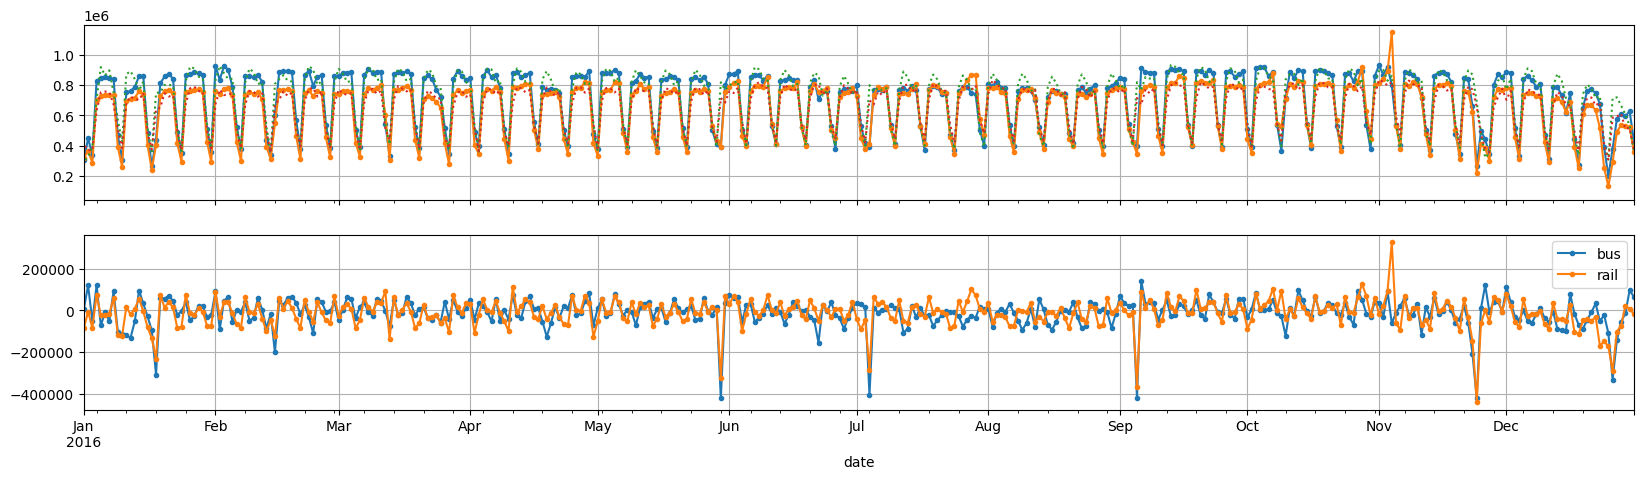

In [76]:
test_pred = model_1.predict(test_ds) * 1e6
test_pred = pd.DataFrame(test_pred, 
                         index=df_bus_rail_test.index[frame_length:], 
                         columns=df_bus_rail_test.columns)

df_bus_rail_test_inv = df_bus_rail_test[frame_length:] * 1e6
test_df_diff = df_bus_rail_test_inv - test_pred

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))

df_bus_rail_test_inv.plot(ax=axs[0], legend=False, marker=".") 
test_pred.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

test_df_diff[period].plot(ax=axs[1], grid=True, marker=".")

In [77]:
mape = (test_df_diff / df_bus_rail_test_inv).abs().mean()
mape

bus     0.089378
rail    0.120128
dtype: float64

### да се тества подаване на типа ден директно към Dense layer-а

In [85]:
df_num = df[['bus', 'rail']].loc[:'2019-12'] / 1e6
df_cat = pd.get_dummies(df['day_type'].shift(-1).loc[:'2019-12']).astype(float)
df_concat = pd.concat([df_num, df_cat], axis=1)

train_ratio = 0.7
train_samples = int(len(df_bus_rail) * train_ratio)

df_train, df_test = df_concat.iloc[:train_samples], df_concat.iloc[train_samples:]

In [100]:
frame_length = 100

def partition(X, y):
    return ((X[:, :, :2], tf.reshape(X[:, :, 2:], [-1, 3 * frame_length])), y)

train_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_train.to_numpy(),
    targets=df_num[:train_samples][frame_length:],
    sequence_length=frame_length,
    batch_size=32,
    shuffle=True,
    seed=42
).map(partition)

test_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_test.to_numpy(),
    targets=df_num[train_samples:][frame_length:],
    sequence_length=frame_length,
    batch_size=32
).map(partition)

In [101]:
next(iter(train_ds))

((<tf.Tensor: shape=(32, 100, 2), dtype=float64, numpy=
  array([[[0.994499, 0.569456],
          [0.586969, 0.268254],
          [0.393359, 0.184628],
          ...,
          [0.965734, 0.571056],
          [0.75523 , 0.472276],
          [0.616271, 0.268843]],
  
         [[1.034023, 0.642939],
          [0.64528 , 0.347387],
          [0.439237, 0.244746],
          ...,
          [0.936684, 0.634107],
          [0.937018, 0.631418],
          [0.640959, 0.397796]],
  
         [[0.53664 , 0.245821],
          [1.111775, 0.633266],
          [1.122716, 0.651484],
          ...,
          [0.770627, 0.431699],
          [0.54286 , 0.314698],
          [0.969826, 0.623874]],
  
         ...,
  
         [[0.990534, 0.591895],
          [1.019785, 0.596338],
          [0.975226, 0.586048],
          ...,
          [0.442112, 0.267216],
          [1.011806, 0.604279],
          [1.010067, 0.606509]],
  
         [[0.443462, 0.319622],
          [1.030602, 0.710784],
          [0.948119

In [102]:
num_inp = tf.keras.layers.Input([100, 2])
x = tf.keras.layers.SimpleRNN(64, return_sequences=True)(num_inp)
x = tf.keras.layers.SimpleRNN(32)(x)

cat_inp = tf.keras.layers.Input([300])
y = tf.keras.layers.Dense(32, activation='relu', kernel_initializer='he_normal')(cat_inp)

concat = tf.keras.layers.concatenate([x, y])
out = tf.keras.layers.Dense(2)(concat)


model_2 = tf.keras.Model(inputs=[num_inp, cat_inp], outputs=out)
model_2.compile(loss=tf.keras.losses.Huber(),
                optimizer=tf.keras.optimizers.Nadam(0.01),
                metrics=['mae', 'mse'])

In [103]:
callbacks = [tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)]
model_2.fit(train_ds, epochs=200, validation_data=test_ds, callbacks=callbacks)

Epoch 1/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 15s 68ms/step - loss: 0.0311 - mae: 0.1173 - mse: 0.0863 - val_loss: 0.0121 - val_mae: 0.1296 - val_mse: 0.0242
Epoch 2/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - loss: 0.0039 - mae: 0.0670 - mse: 0.0078 - val_loss: 0.0106 - val_mae: 0.1240 - val_mse: 0.0212
Epoch 3/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.0033 - mae: 0.0622 - mse: 0.0065 - val_loss: 0.0139 - val_mae: 0.1489 - val_mse: 0.0279
Epoch 4/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - loss: 0.0033 - mae: 0.0622 - mse: 0.0066 - val_loss: 0.0112 - val_mae: 0.1289 - val_mse: 0.0224
Epoch 5/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0030 - mae: 0.0597 - mse: 0.0060 - val_loss: 0.0121 - val_mae: 0.1294 - val_mse: 0.0243
Epoch 6/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0031 - mae: 0.0604 - mse: 0.0063 - val_loss: 0.0046 - val_mae: 0.0808 - val_mse: 0.0093
Epoch 7/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 0.0028 - mae: 0.0566 

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step


<Axes: xlabel='date'>

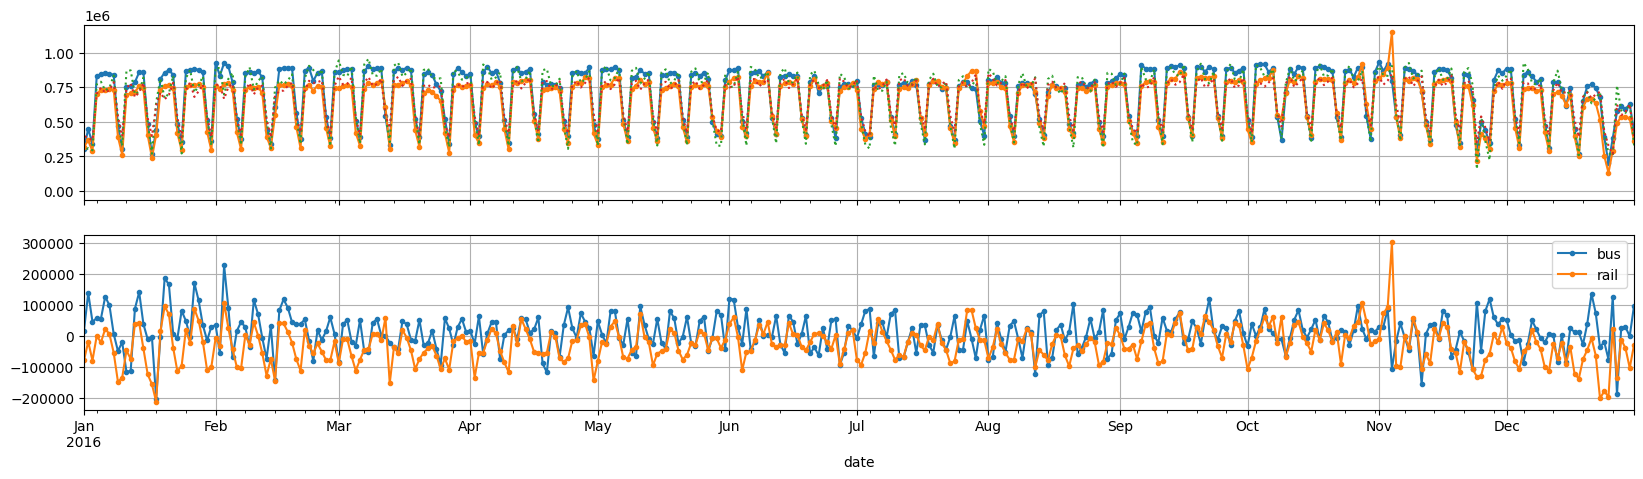

In [104]:
test_pred = model_2.predict(test_ds) * 1e6
test_pred = pd.DataFrame(test_pred, 
                         index=df_bus_rail_test.index[frame_length:], 
                         columns=df_bus_rail_test.columns)

df_bus_rail_test_inv = df_num[train_samples:][frame_length:] * 1e6
test_df_diff = df_bus_rail_test_inv - test_pred

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))

df_bus_rail_test_inv.plot(ax=axs[0], legend=False, marker=".") 
test_pred.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

test_df_diff[period].plot(ax=axs[1], grid=True, marker=".")

In [105]:
mape_2 = (test_df_diff / df_bus_rail_test_inv).abs().mean()
mape_2

bus     0.085568
rail    0.119224
dtype: float64

### да се тества подаване на типа ден директно към RNN layer-а

In [106]:
frame_length = 100

train_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_train.to_numpy(),
    targets=df_num[:train_samples][frame_length:],
    sequence_length=frame_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_test.to_numpy(),
    targets=df_num[train_samples:][frame_length:],
    sequence_length=frame_length,
    batch_size=32
)

In [ ]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(2)
])

model_3.compile(loss=tf.keras.losses.Huber(),
                optimizer=tf.keras.optimizers.Nadam(0.01),
                metrics=['mae', 'mse'])

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [109]:
callbacks = [tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)]
model_3.fit(train_ds, epochs=200, validation_data=test_ds, callbacks=callbacks)

Epoch 1/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - loss: 0.0220 - mae: 0.0986 - mse: 0.0487 - val_loss: 0.0086 - val_mae: 0.1125 - val_mse: 0.0172
Epoch 2/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - loss: 0.0030 - mae: 0.0582 - mse: 0.0060 - val_loss: 0.0067 - val_mae: 0.0968 - val_mse: 0.0134
Epoch 3/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - loss: 0.0024 - mae: 0.0521 - mse: 0.0049 - val_loss: 0.0064 - val_mae: 0.0977 - val_mse: 0.0127
Epoch 4/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - loss: 0.0024 - mae: 0.0514 - mse: 0.0048 - val_loss: 0.0072 - val_mae: 0.1016 - val_mse: 0.0144
Epoch 5/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - loss: 0.0021 - mae: 0.0481 - mse: 0.0042 - val_loss: 0.0029 - val_mae: 0.0580 - val_mse: 0.0058
Epoch 6/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - loss: 0.0020 - mae: 0.0465 - mse: 0.0039 - val_loss: 0.0025 - val_mae: 0.0545 - val_mse: 0.0050
Epoch 7/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - loss: 0.0019 - mae: 0.045

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step


<Axes: xlabel='date'>

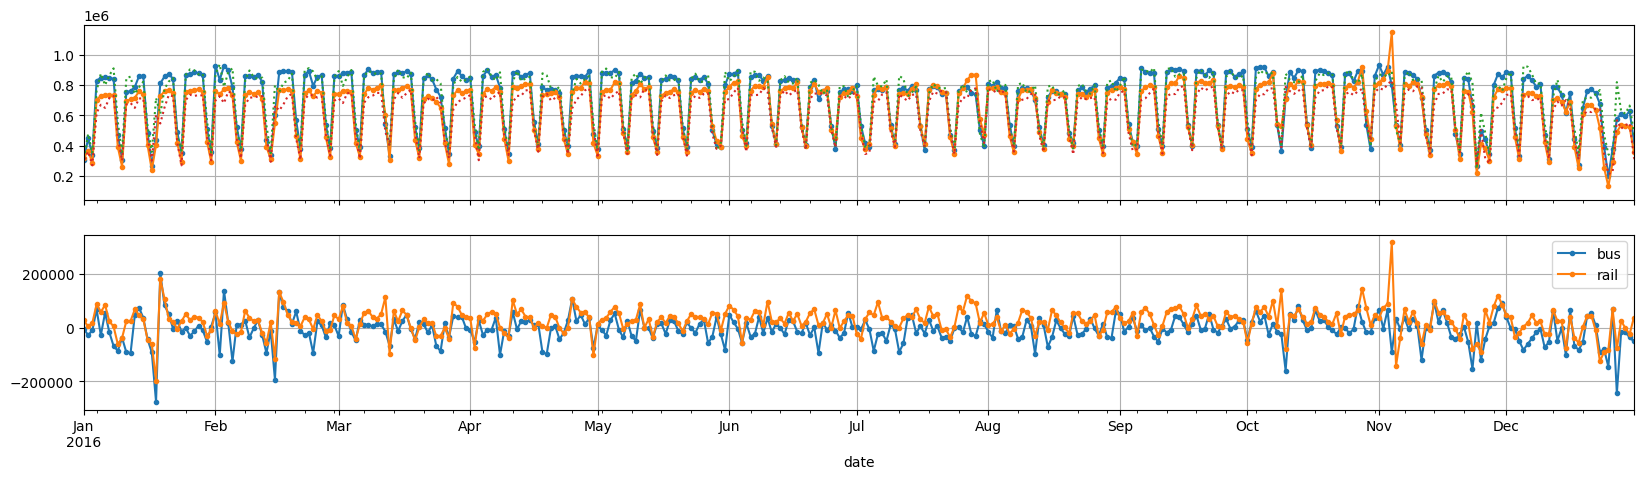

In [110]:
test_pred = model_3.predict(test_ds) * 1e6
test_pred = pd.DataFrame(test_pred, 
                         index=df_bus_rail_test.index[frame_length:], 
                         columns=df_bus_rail_test.columns)

df_bus_rail_test_inv = df_num[train_samples:][frame_length:] * 1e6
test_df_diff = df_bus_rail_test_inv - test_pred

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))

df_bus_rail_test_inv.plot(ax=axs[0], legend=False, marker=".") 
test_pred.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

test_df_diff[period].plot(ax=axs[1], grid=True, marker=".")

In [111]:
mape_3 = (test_df_diff / df_bus_rail_test_inv).abs().mean()
mape_3

bus     0.064235
rail    0.076316
dtype: float64

### тест с по слойна архитектура 

In [116]:
model_4 = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(16),

    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(16, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(2)
])

model_4.compile(loss=tf.keras.losses.Huber(),
                optimizer=tf.keras.optimizers.Nadam(0.01),
                metrics=['mae', 'mse'])

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [117]:
callbacks = [tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)]
model_4.fit(train_ds, epochs=200, validation_data=test_ds, callbacks=callbacks)

Epoch 1/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - loss: 0.0436 - mae: 0.2094 - mse: 0.0900 - val_loss: 0.0093 - val_mae: 0.1146 - val_mse: 0.0187
Epoch 2/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0088 - mae: 0.1042 - mse: 0.0177 - val_loss: 0.0110 - val_mae: 0.1235 - val_mse: 0.0220
Epoch 3/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - loss: 0.0059 - mae: 0.0846 - mse: 0.0119 - val_loss: 0.0106 - val_mae: 0.1241 - val_mse: 0.0211
Epoch 4/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0046 - mae: 0.0734 - mse: 0.0092 - val_loss: 0.0146 - val_mae: 0.1354 - val_mse: 0.0292
Epoch 5/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0042 - mae: 0.0692 - mse: 0.0084 - val_loss: 0.0099 - val_mae: 0.1227 - val_mse: 0.0199
Epoch 6/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0038 - mae: 0.0664 - mse: 0.0077 - val_loss: 0.0120 - val_mae: 0.1364 - val_mse: 0.0240
Epoch 7/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - loss: 0.0038 - mae: 0.065

62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step


<Axes: xlabel='date'>

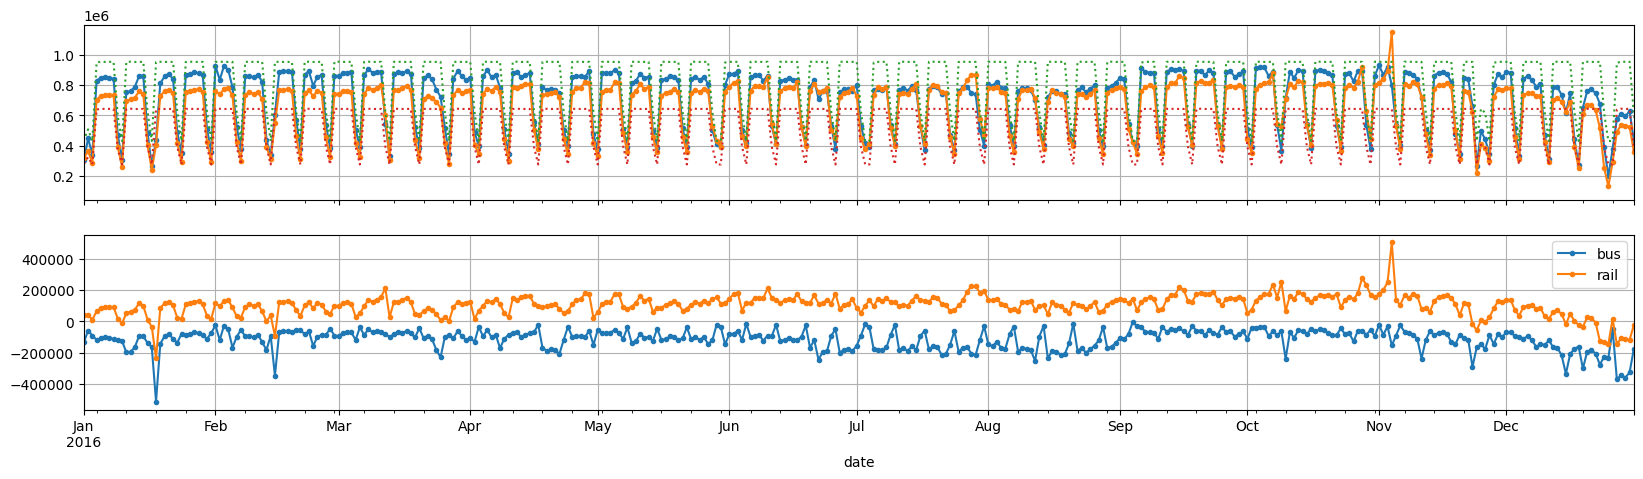

In [118]:
test_pred = model_4.predict(test_ds) * 1e6
test_pred = pd.DataFrame(test_pred, 
                         index=df_bus_rail_test.index[frame_length:], 
                         columns=df_bus_rail_test.columns)

df_bus_rail_test_inv = df_num[train_samples:][frame_length:] * 1e6
test_df_diff = df_bus_rail_test_inv - test_pred

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))

df_bus_rail_test_inv.plot(ax=axs[0], legend=False, marker=".") 
test_pred.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

test_df_diff[period].plot(ax=axs[1], grid=True, marker=".")

In [119]:
mape_4 = (test_df_diff / df_bus_rail_test_inv).abs().mean()
mape_4

bus     0.205318
rail    0.163915
dtype: float64

In [123]:
inxs_0 = pd.Series(['Num->2SimpleRnn', 
                    'Num->2SimpleRNN+Cat->Dense', 
                    'Num+Cat->2SimpleRNN', 
                    'Num+Cat->3SimpleRNN->DOUT->2Den'
                    ]).repeat(2)

res = pd.concat([mape, mape_2, mape_3, mape_4])
res.name = 'MAPE RESULTS'
res.index = pd.MultiIndex.from_arrays([inxs_0, res.index])
res.sort_values()

Num+Cat->2SimpleRNN              bus     0.064235
                                 rail    0.076316
Num->2SimpleRNN+Cat->Dense       bus     0.085568
Num->2SimpleRnn                  bus     0.089378
Num->2SimpleRNN+Cat->Dense       rail    0.119224
Num->2SimpleRnn                  rail    0.120128
Num+Cat->3SimpleRNN->DOUT->2Den  rail    0.163915
                                 bus     0.205318
Name: MAPE RESULTS, dtype: float64

### добавяне на допълнителен feature

In [125]:
df_num = df[['bus', 'rail']].loc[:'2019-12'] / 1e6
df_cat = pd.get_dummies(df['day_type'].shift(-1).loc[:'2019-12']).astype(float)
df_concat = pd.concat([df_num, df_cat], axis=1)
df_concat['total'] = df_num.sum(axis=1)

train_ratio = 0.7
train_samples = int(len(df_bus_rail) * train_ratio)

df_train, df_test = df_concat.iloc[:train_samples], df_concat.iloc[train_samples:]

In [127]:
frame_length = 100

train_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_train.to_numpy(),
    targets=df_num[:train_samples][frame_length:],
    sequence_length=frame_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_test.to_numpy(),
    targets=df_num[train_samples:][frame_length:],
    sequence_length=frame_length,
    batch_size=32
)

In [128]:
model_5 = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 6]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(2)
])

model_5.compile(loss=tf.keras.losses.Huber(),
                optimizer=tf.keras.optimizers.Nadam(0.01),
                metrics=['mae', 'mse'])

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [129]:
callbacks = [tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)]
model_5.fit(train_ds, epochs=200, validation_data=test_ds, callbacks=callbacks)

Epoch 1/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - loss: 0.0159 - mae: 0.0891 - mse: 0.0349 - val_loss: 0.0095 - val_mae: 0.1211 - val_mse: 0.0190
Epoch 2/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.0028 - mae: 0.0562 - mse: 0.0055 - val_loss: 0.0092 - val_mae: 0.1198 - val_mse: 0.0184
Epoch 3/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - loss: 0.0024 - mae: 0.0519 - mse: 0.0048 - val_loss: 0.0050 - val_mae: 0.0769 - val_mse: 0.0099
Epoch 4/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0024 - mae: 0.0517 - mse: 0.0048 - val_loss: 0.0064 - val_mae: 0.0985 - val_mse: 0.0127
Epoch 5/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0024 - mae: 0.0512 - mse: 0.0048 - val_loss: 0.0106 - val_mae: 0.1197 - val_mse: 0.0212
Epoch 6/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.0022 - mae: 0.0491 - mse: 0.0044 - val_loss: 0.0087 - val_mae: 0.1084 - val_mse: 0.0174
Epoch 7/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.0021 - mae: 0.047

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step


<Axes: xlabel='date'>

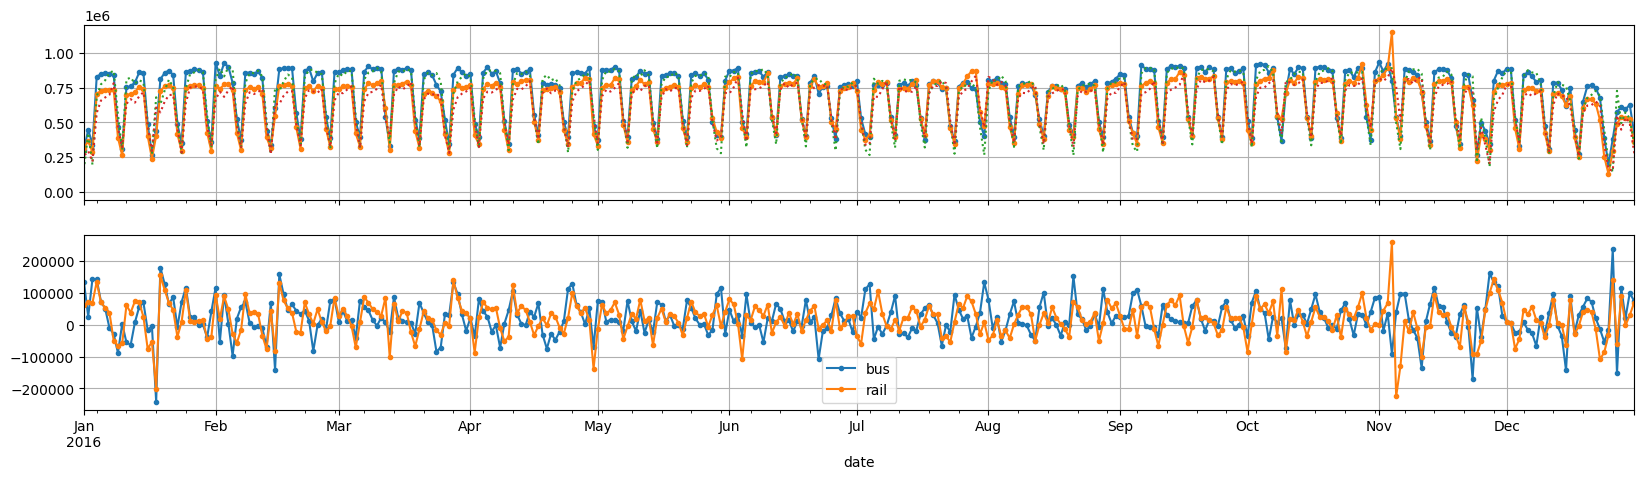

In [130]:
test_pred = model_5.predict(test_ds) * 1e6
test_pred = pd.DataFrame(test_pred, 
                         index=df_bus_rail_test.index[frame_length:], 
                         columns=df_bus_rail_test.columns)

df_bus_rail_test_inv = df_num[train_samples:][frame_length:] * 1e6
test_df_diff = df_bus_rail_test_inv - test_pred

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))

df_bus_rail_test_inv.plot(ax=axs[0], legend=False, marker=".") 
test_pred.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

test_df_diff[period].plot(ax=axs[1], grid=True, marker=".")

In [131]:
mape_5 = (test_df_diff / df_bus_rail_test_inv).abs().mean()
mape_5

bus     0.086390
rail    0.083694
dtype: float64

In [2]:
from keras_tuner import kt

def build_model(hp: kt.HyperParameters):
    p = hp.Int('p', 0, 3)
    d = hp.Int('d', 0, 2)
    q = hp.Int('q', 0, 3)

    P = hp.Int('P', 0, 2)
    D = hp.Int('D', 0, 2)
    Q = hp.Int('Q', 0, 2)
    # s = hp.Choice('s', [7, 28, 7 * 52])

    return ARIMA_TF(train, order=(p, d, q), seasonal_order=(P, D, Q, 7))

2026-02-15 18:17:12.414480: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-15 18:17:13.224752: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 18:17:22.374441: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


ImportError: cannot import name 'kt' from 'keras_tuner' (/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras_tuner/__init__.py)

In [ ]:
search = kt.GridSearch(build_model, 'val_mape', directory="my_dir", project_name="arima")
search.get_best_models(num_models=1)
